In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import  matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import PowerTransformer,OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.metrics import roc_curve,roc_auc_score
df = pd.read_csv('/content/patient_adherence_dataset.csv')
df_original = df.copy()
print('\nDataset_information')
print('---------')
df.head(5)





Dataset_information
---------


,Age,Gender,Medication_Type,Dosage_mg,Previous_Adherence,Education_Level,Income,Social_Support_Level,Condition_Severity,Comorbidities_Count,Healthcare_Access,Mental_Health_Status,Insurance_Coverage,Adherence
0,57,Male,TypeA,136,1,High School,634934,Medium,Severe,3,Poor,Good,1,1
1,47,Male,TypeA,134,1,High School,297954,High,Moderate,3,Good,Good,1,0
2,59,Male,TypeC,89,1,High School,789337,High,Moderate,1,Good,Good,1,1
3,72,Male,TypeB,240,0,Postgraduate,267352,Low,Mild,2,Poor,Moderate,1,0
4,46,Male,TypeA,241,1,Postgraduate,718447,Medium,Mild,1,Poor,Good,1,0


In [52]:
df['Adherence'].value_counts()
# Balanced Dataset

,count
Adherence,
0,2714
1,2286


In [53]:
print(df.info())
print('Dataset_Shape:',df.shape)
print(df.select_dtypes(include=['int64' or 'float64']).skew())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   5000 non-null   int64 
 1   Gender                5000 non-null   object
 2   Medication_Type       5000 non-null   object
 3   Dosage_mg             5000 non-null   int64 
 4   Previous_Adherence    5000 non-null   int64 
 5   Education_Level       5000 non-null   object
 6   Income                5000 non-null   int64 
 7   Social_Support_Level  5000 non-null   object
 8   Condition_Severity    5000 non-null   object
 9   Comorbidities_Count   5000 non-null   int64 
 10  Healthcare_Access     5000 non-null   object
 11  Mental_Health_Status  5000 non-null   object
 12  Insurance_Coverage    5000 non-null   int64 
 13  Adherence             5000 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 547.0+ KB
None
Dataset_Shape: (5000, 14)
Age       

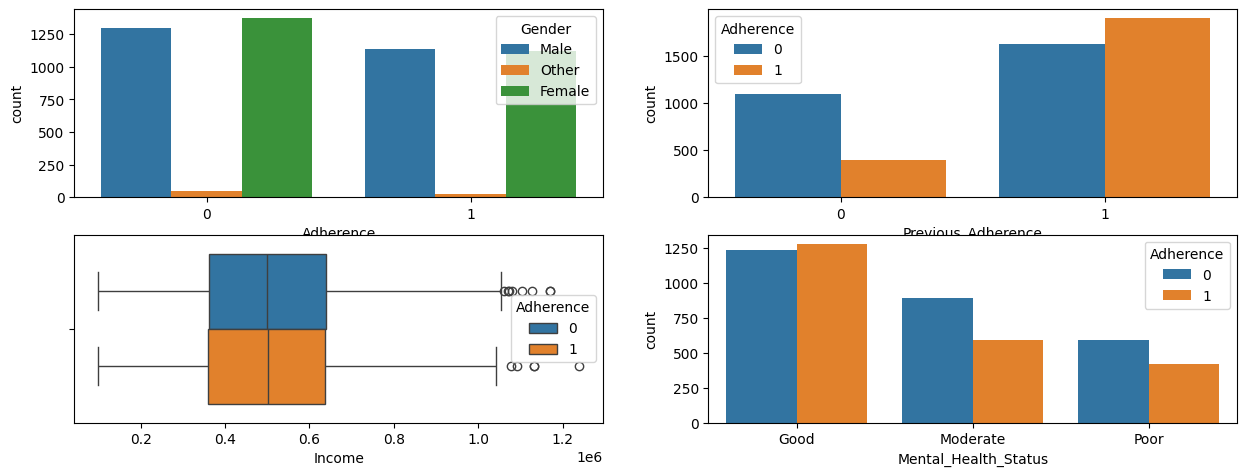

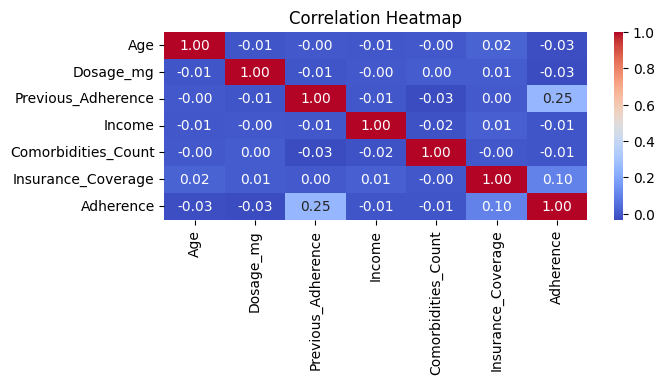

                 Age         Income   Dosage_mg  Previous_Adherence
Adherence                                                          
0          50.030582  502667.417097  202.360722            0.596168
1          49.232283  498840.928696  199.150481            0.828521


In [54]:
#EDA
plt.figure(figsize=(15,20))
plt.subplot(7,2,1)
sns.countplot(x=df['Adherence'],hue = 'Gender',data = df)
plt.subplot(7,2,2)
sns.countplot(x='Previous_Adherence',
              hue='Adherence',
              data=df)
plt.subplot(7,2,3)
sns.boxplot( x= df['Income'],hue='Adherence',data = df)
plt.subplot(7,2,4)
sns.countplot(x='Mental_Health_Status',
              hue='Adherence',
              data=df)
plt.figure(figsize=(15,20))

corr = df.select_dtypes(include=['int64','float64']).corr()
plt.subplot(7,2,5)
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()
print(df.groupby('Adherence')[
    ['Age',
     'Income',
     'Dosage_mg',
     'Previous_Adherence']
].mean())
y = df['Adherence']
x = df.drop('Adherence',axis =1)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state=42)

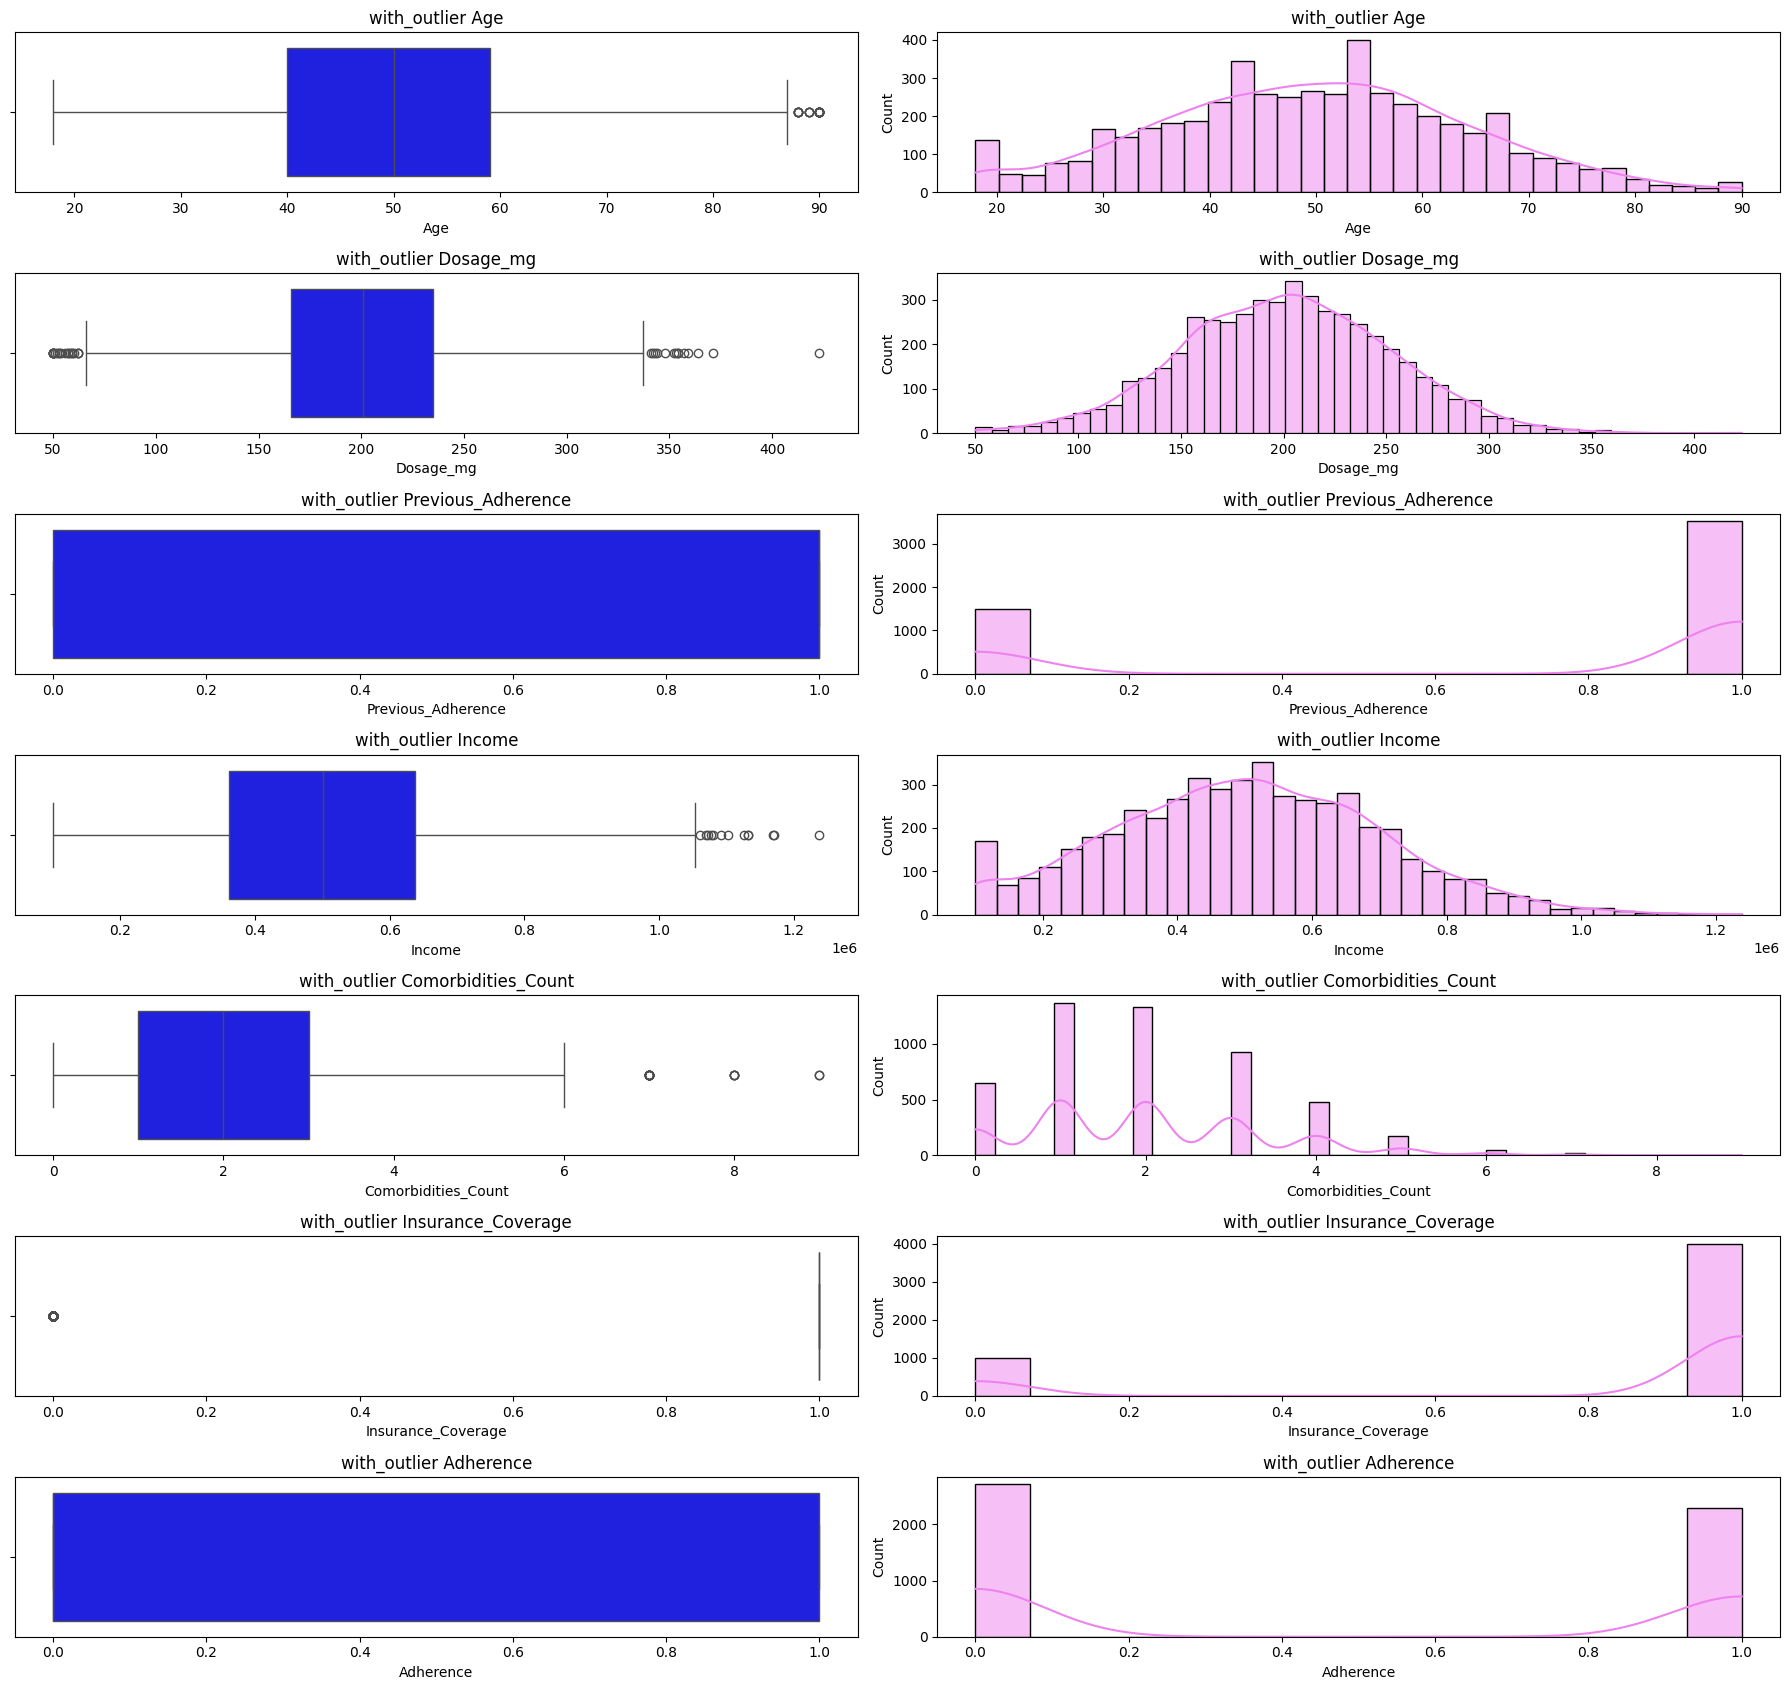


 Skewness_Values:
----------
Age                     0
Gender                  0
Medication_Type         0
Dosage_mg               0
Previous_Adherence      0
Education_Level         0
Income                  0
Social_Support_Level    0
Condition_Severity      0
Comorbidities_Count     0
Healthcare_Access       0
Mental_Health_Status    0
Insurance_Coverage      0
Adherence               0
dtype: int64


In [55]:
#outlier
num_col = df.select_dtypes(include=['int64']).columns
plt.figure(figsize=(18,17))
#BoxPlot to determine outliers
for i,col in enumerate(num_col):
  if df_original[col].dtype == 'int64':
    plt.subplot(len(num_col),2,2*i+1)
    sns.boxplot(x = df_original[col],data = df,color = 'blue')
    plt.title(f'with_outlier {col}')
for i,col in enumerate(num_col):
  if df_original[col].dtype == 'int64':
    plt.subplot(len(num_col),2,2*i+2)
    sns.histplot(x = df_original[col],data = df,kde= True,color = 'violet')
    plt.title(f'with_outlier {col}')
plt.tight_layout()
plt.show()
#skewness_checking
new_df = df.select_dtypes(include=['float64'])
print('\n Skewness_Values:')
print('----------')
print(df.isnull().sum())
#FeatureEngineering
df['Mental_Health_Status'].unique()
y = df['Adherence']
x = df.drop('Adherence',axis =1)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3,random_state=42)


In [56]:
cat = df.select_dtypes(include='object')
cat['Adherence'] = df['Adherence']
cat_col = cat.drop(['Adherence','Gender','Medication_Type'],axis =1).columns
cat_col
for i,col in enumerate(cat_col):
  print(cat.groupby('Adherence')[col].value_counts().reset_index())

   Adherence Education_Level  count
0          0     High School   1161
1          0        Graduate   1109
2          0    Postgraduate    444
3          1     High School    901
4          1        Graduate    842
5          1    Postgraduate    543
   Adherence Social_Support_Level  count
0          0               Medium   1131
1          0                  Low    897
2          0                 High    686
3          1               Medium    855
4          1                 High    802
5          1                  Low    629
   Adherence Condition_Severity  count
0          0               Mild   1239
1          0           Moderate    887
2          0             Severe    588
3          1               Mild   1296
4          1           Moderate    578
5          1             Severe    412
   Adherence Healthcare_Access  count
0          0           Average   1184
1          0              Good    956
2          0              Poor    574
3          1              Good   101

In [57]:
df.select_dtypes(include=['object']).columns

Index(['Gender', 'Medication_Type', 'Education_Level', 'Social_Support_Level',
       'Condition_Severity', 'Healthcare_Access', 'Mental_Health_Status'],
      dtype='object')

In [67]:
#ordinalEncoding
print(df['Mental_Health_Status'].unique())
class outliercapper(BaseEstimator,TransformerMixin):
  def fit(self,x,y=None):
    q1 = np.percentile(x,25,axis=0)
    q3 = np.percentile(x,75,axis=0)
    self.lower = q1-1.5*(q3-q1)
    self.upper = q3+1.5*(q3-q1)
    return self
  def transform(self,x):
    x = np.clip(x,self.lower,self.upper)
    return x
  def get_feature_names_out(self, input_features=None):
        return input_features
num_pipe = Pipeline([('outlier',outliercapper()),('power',PowerTransformer()),('scale',StandardScaler())])
ord_pipe = Pipeline([('ord',OrdinalEncoder(categories=[['High School' ,'Graduate','Postgraduate'],['Low', 'Medium','High'],['Mild','Moderate','Severe'],
                                                      ['Poor', 'Average', 'Good'],['Poor','Moderate','Good']]))])
ohe_pipe= Pipeline([('ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))])
preprocessor1 = ColumnTransformer([('num',num_pipe,['Income']),('ord',ord_pipe,['Education_Level','Social_Support_Level','Condition_Severity','Healthcare_Access','Mental_Health_Status']),
                                               ('ohe',ohe_pipe,['Gender', 'Medication_Type'])],remainder= 'passthrough')
main_pipe_1 = Pipeline([('preprocessor1',preprocessor1),('model',LogisticRegression())])
param_grid_1 = [

    {'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear', 'saga']},


{
    "model":[SVC(probability=True)],
    "model__C":[0.1,1,10],
    "model__kernel":["rbf"]
}

]
grid1 = GridSearchCV(estimator=main_pipe_1,param_grid= param_grid_1,cv = 5,scoring ='roc_auc',n_jobs = -1)
grid1.fit(x_train,y_train)
print('best_estimator:',grid1.best_params_)
print('best_score of the model:',grid1.best_score_)

['Good' 'Moderate' 'Poor']
best_estimator: {'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
best_score of the model: 0.681459050112743


In [79]:
#Using Boosting Algorithms
preprocessor2 = ColumnTransformer([('ord',ord_pipe,['Education_Level','Social_Support_Level','Condition_Severity','Healthcare_Access','Mental_Health_Status']),
                                               ('ohe',ohe_pipe,['Gender', 'Medication_Type'])],remainder= 'passthrough')
main_pipe_2 = Pipeline([('preprocessor2',preprocessor2),('model',XGBClassifier())])
param_grid_2 = [{
        'model': [DecisionTreeClassifier()],
        'model__max_depth': [3, 5, 10, 20, None],
        'model__min_samples_split': [2, 5, 10]
    },

   {

 'model':[RandomForestClassifier()],
 'model__n_estimators':[100,150,200],
 'model__max_depth':[5,10,15,None],
 'model__min_samples_split':[2,5,10],
 'model__min_samples_leaf':[1,2,4]

}
    ,{
    "model":[GradientBoostingClassifier(random_state=42)],
    "model__n_estimators":[100,200],
    "model__learning_rate":[0.05,0.1],
    "model__max_depth":[3,5]
},{

    'model':[XGBClassifier()],
    'model__n_estimators': [200,300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__min_child_weight': [1, 3, 5],
    'model__gamma': [0, 0.1, 0.3, 0.5],
    'model__reg_alpha': [0, 0.01, 0.1, 1],
    'model__reg_lambda': [1, 2, 5, 10]

}]
grid2= RandomizedSearchCV(estimator=main_pipe_2,param_distributions=param_grid_2,cv=5,scoring='roc_auc',n_jobs=-1)
grid2.fit(x_train,y_train)
print('best_estimator:',grid2.best_params_)
print('best_socre of the model:',grid2.best_score_)

best_estimator: {'model__subsample': 1.0, 'model__reg_lambda': 10, 'model__reg_alpha': 0.1, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__gamma': 0.3, 'model__colsample_bytree': 1.0, 'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_

accuracy_score: 0.65
classification_report:               precision    recall  f1-score   support

           0       0.68      0.67      0.67       806
           1       0.62      0.63      0.62       694

    accuracy                           0.65      1500
   macro avg       0.65      0.65      0.65      1500
weighted avg       0.65      0.65      0.65      1500



<Axes: >

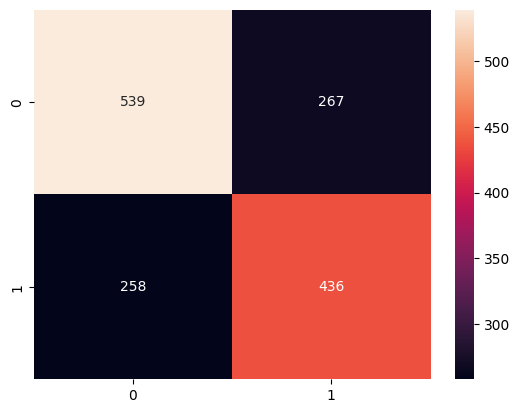

In [80]:
#Prediction
y_pred = grid2.predict(x_test)
print('accuracy_score:',accuracy_score(y_test,y_pred))
print('classification_report:',classification_report(y_test,y_pred))
cm  = confusion_matrix(y_test,y_pred)
#plotting Confusion_Matrix
sns.heatmap(cm,annot = True,fmt = 'd')

accuracy_score: 0.6346666666666667
classification_report:               precision    recall  f1-score   support

           0       0.66      0.67      0.66       806
           1       0.61      0.59      0.60       694

    accuracy                           0.63      1500
   macro avg       0.63      0.63      0.63      1500
weighted avg       0.63      0.63      0.63      1500



<Axes: >

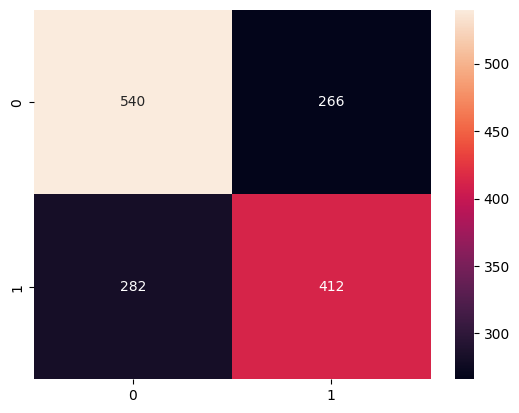

In [81]:
y_pred1 = grid1.predict(x_test)
print('accuracy_score:',accuracy_score(y_test,y_pred1))
print('classification_report:',classification_report(y_test,y_pred1))
cm  = confusion_matrix(y_test,y_pred1)
#plotting Confusion_Matrix
sns.heatmap(cm,annot = True,fmt = 'd')

                 features  importance
13     Previous_Adherence    0.451857
16     Insurance_Coverage    0.087512
1    Social_Support_Level    0.086250
4    Mental_Health_Status    0.068010
2      Condition_Severity    0.052847
3       Healthcare_Access    0.049109
0         Education_Level    0.043209
5           Gender_Female    0.031448
14                 Income    0.029424
9   Medication_Type_TypeB    0.026012
12              Dosage_mg    0.025889
11                    Age    0.025115
15    Comorbidities_Count    0.023318
8   Medication_Type_TypeA    0.000000
7            Gender_Other    0.000000
6             Gender_Male    0.000000
10  Medication_Type_TypeC    0.000000


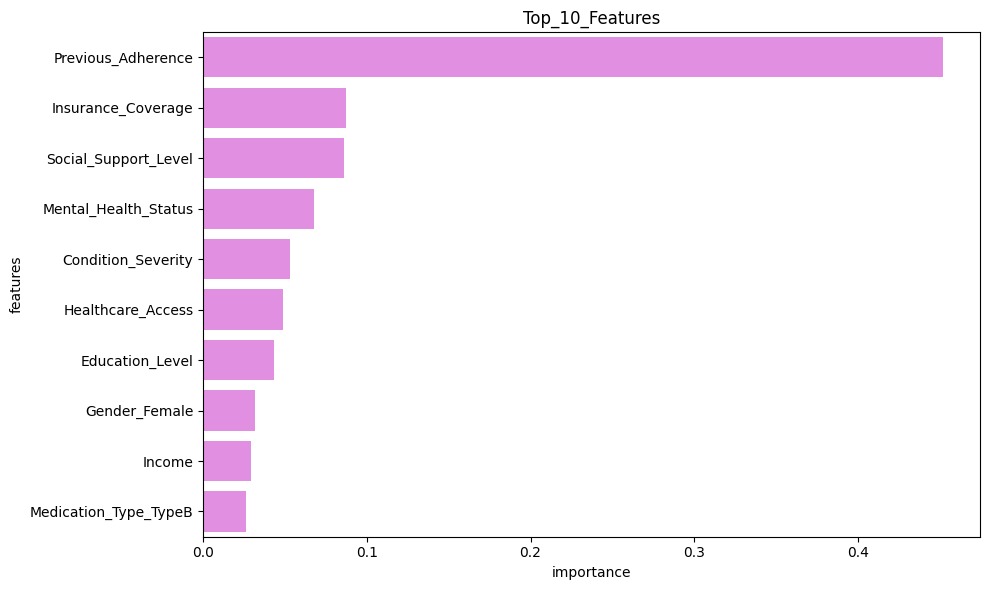

In [82]:
#Feature_importance
best_model = grid2.best_estimator_
preprocessor = best_model.named_steps['preprocessor2']
feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split('__')[-1] for name in feature_names]
rf_model = best_model.named_steps['model']
feature_importance = pd.DataFrame({'features':feature_names,'importance':rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(by = 'importance',ascending=False)
print(feature_importance)
plt.figure(figsize=(10,6))
sns.barplot(y= 'features',x='importance',data = feature_importance.head(10),color= 'violet')
plt.title('Top_10_Features')
plt.tight_layout()
plt.show()

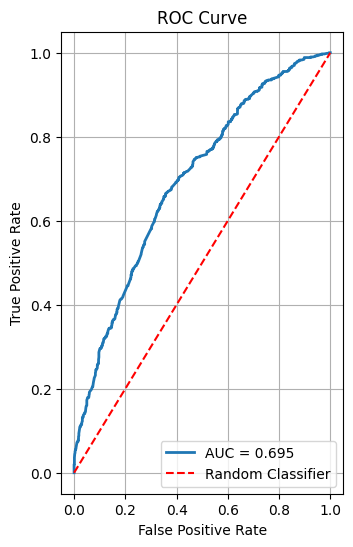

ROC-AUC Score: 0.6947041640148454


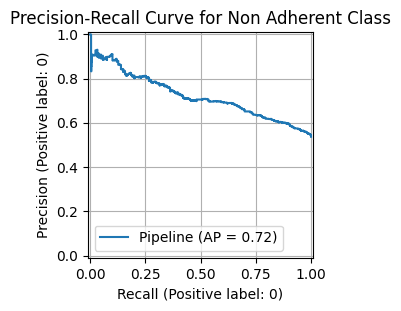

In [83]:
#ROC Curve
best_model = grid2.best_estimator_
y_prob =  best_model.predict_proba(x_test)[:,1]
fpr,tpr,thresholds = roc_curve(y_test,y_prob)
auc_score = roc_auc_score(y_test,y_prob)
# Plot ROC Curve
plt.figure(figsize=(8,6))
plt.subplot(1,2,1)
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AUC = {auc_score:.3f}'
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='red',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
print("ROC-AUC Score:", auc_score)

#Precision_Recall_Curve
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt
plt.subplot(1,2,2)
PrecisionRecallDisplay.from_estimator(
    best_model,
    x_test,
    y_test,
    pos_label=0,
    ax=plt.gca()
)

plt.title("Precision-Recall Curve for Non Adherent Class")
plt.grid(True)
plt.show()

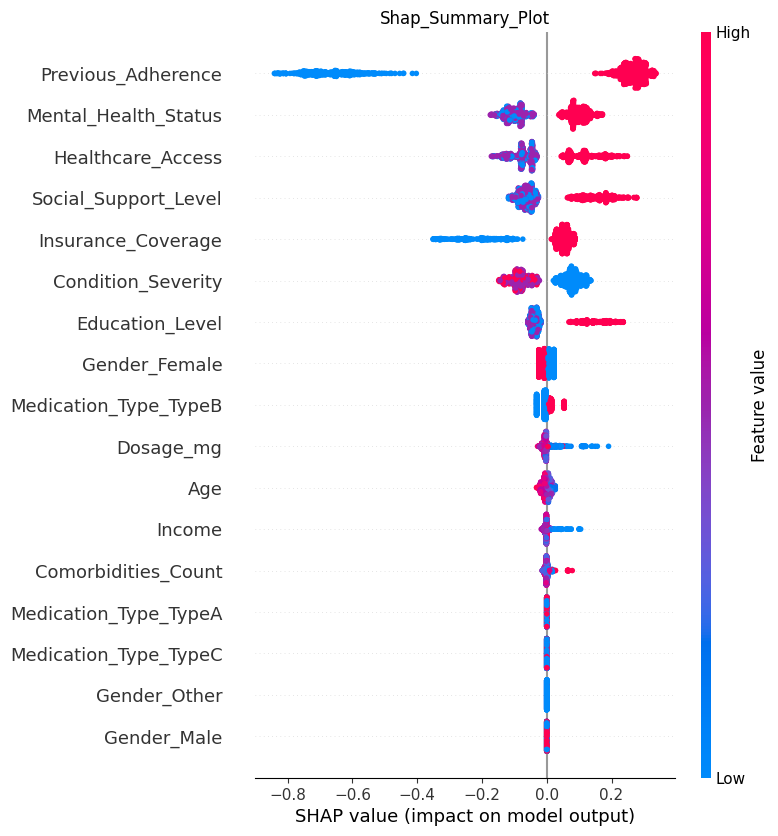

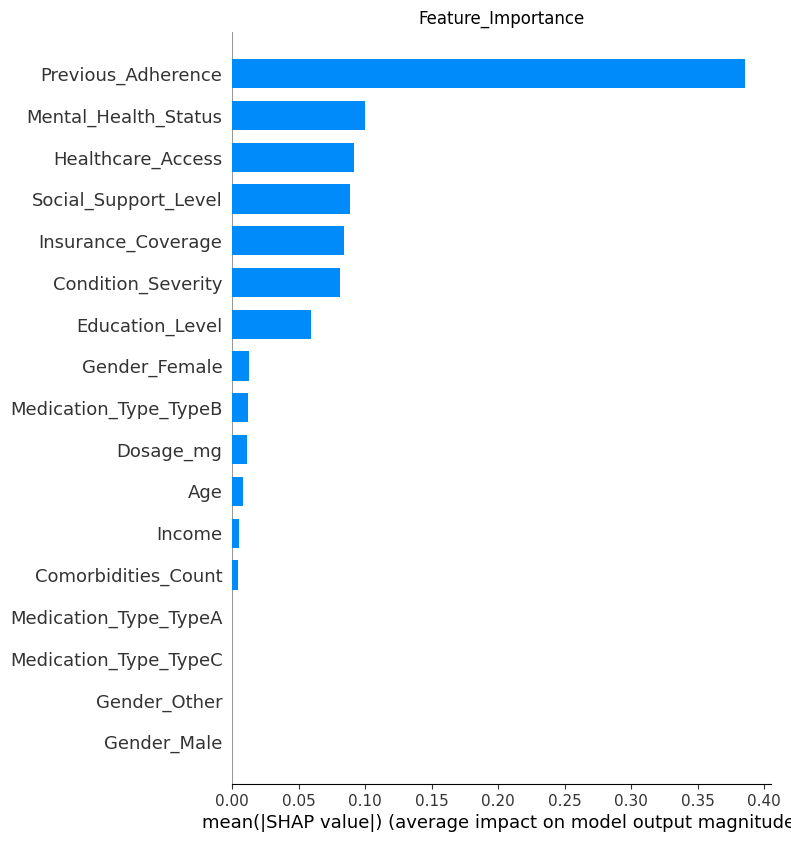

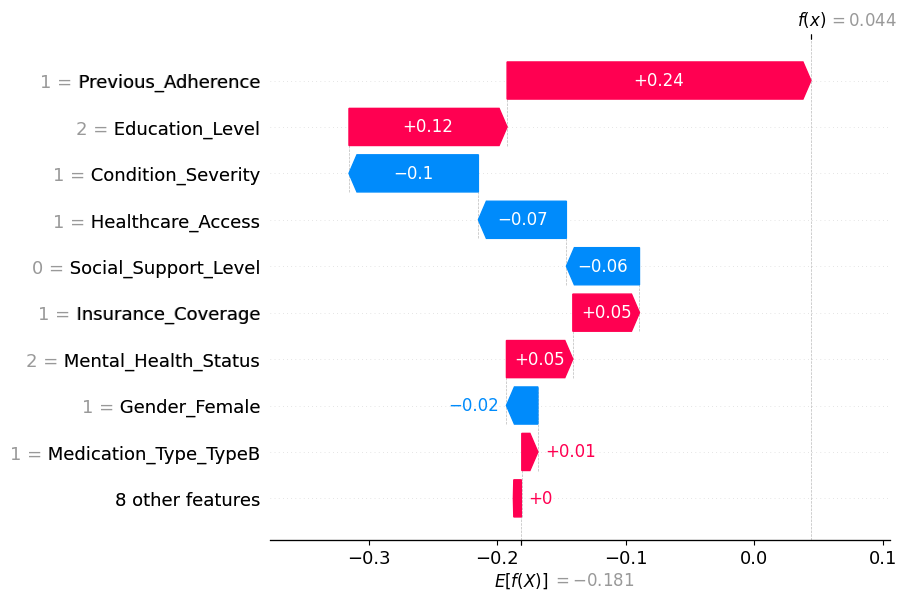

In [84]:
#Shap_Analysis
import shap
preprocessor = best_model.named_steps['preprocessor2']
feature_names = preprocessor.get_feature_names_out()
x_train_trans = preprocessor.transform(x_train)
x_test_trans = preprocessor.transform(x_test)
feature_names = [name.split('__')[-1] for name in feature_names]
x_train_trans = pd.DataFrame(x_train_trans,columns = feature_names)
x_test_trans = pd.DataFrame(x_test_trans,columns = feature_names)
rf_model= best_model.named_steps['model']
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(x_test_trans)
plt.figure()
shap.summary_plot(shap_values,x_test_trans,show=False)
plt.title('Shap_Summary_Plot')
plt.show()
plt.figure()
shap.summary_plot(shap_values,x_test_trans,plot_type = 'bar',show= False)
plt.title('Feature_Importance')
plt.show()
sample_index =0
shap.plots.waterfall(
    shap.Explanation(
        values = shap_values[sample_index,:],
        base_values = explainer.expected_value,
        data = x_test_trans.iloc[sample_index],
        feature_names = x_test_trans.columns
    )
)

In [88]:
import pickle

with open("patient_Adherence_prediction_final.pkl", "wb") as file:
    pickle.dump(best_model, file)

In [89]:
import sklearn
print(sklearn.__version__)

1.6.1


In [91]:
y_test

,Adherence
1501,1
2586,1
2653,1
1055,0
705,1
...,...
3563,0
1538,0
1837,0
2380,0
